# Classification



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import confusion_matrix
from sklearn import datasets
from sklearn.pipeline import Pipeline

# 2진 분류(binary-class classification)문제

* breast cancer 데이터에서 Malignant/Benign 분류
* KNN classifier
* Logistic regression
* SGD classifier

In [2]:
cancer=datasets.load_breast_cancer()
cancer

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [3]:
cancer.target_names

array(['malignant', 'benign'], dtype='<U9')

In [4]:
x=cancer.data
y=cancer.target

In [5]:
x_train, x_test, y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [6]:
x_train.shape,y_train.shape

((455, 30), (455,))

In [7]:
# pipe=Pipeline(steps=[('KNN',KNeighborsClassifier()),('logi',LogisticRegression(random_state=42)),('SGD',SGDClassifier())])
knn=KNeighborsClassifier()
pipe=Pipeline(steps=[('scaler',StandardScaler()),('knn',KNeighborsClassifier())])
# logi=LogisticRegression(random_state=42)
# SGD=SGDClassifier()

In [8]:
pipe.fit(x_train,y_train)
# knn.fit(x_train,y_train)
# logi.fit(x_train,y_train)
# SGD.fit(x_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])

In [9]:
knnpred=pipe.predict(x_test)

In [10]:
cmk=confusion_matrix(y_test,knnpred)

In [11]:
pipe.score(x_train,y_train)

0.9736263736263736

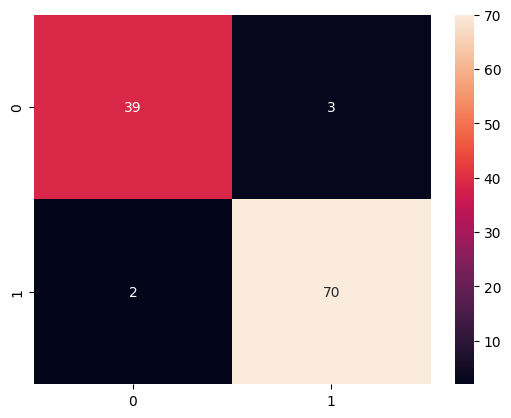

In [12]:
sns.heatmap(data=cmk,annot=True)
plt.show()

In [13]:
pipe=Pipeline(steps=[('scaler',StandardScaler()),('logi',LogisticRegression(random_state=42))])

In [14]:
pipe.fit(x_train,y_train)
# SGD.fit(x_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logi', LogisticRegression(random_state=42))])

In [15]:
logipred=pipe.predict(x_test)

In [16]:
pipe.score(x_train,y_train)

0.989010989010989

In [17]:
cml=confusion_matrix(y_test,logipred)

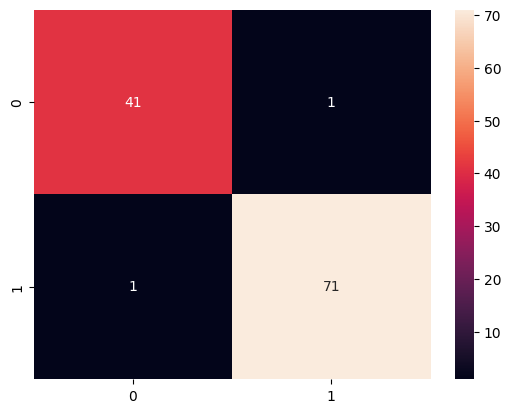

In [18]:
sns.heatmap(data=cml,annot=True)
plt.show()

In [19]:
pipe=Pipeline(steps=[('scaler',StandardScaler()),('SGD',SGDClassifier())])

In [20]:
# logi.fit(x_train,y_train)
pipe.fit(x_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('SGD', SGDClassifier())])

In [21]:
pipe.score(x_train,y_train)

0.9824175824175824

In [22]:
sgdpred=pipe.predict(x_test)

In [23]:
cms=confusion_matrix(y_test,sgdpred)

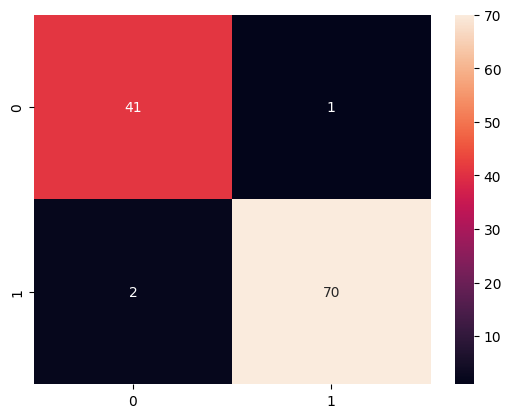

In [24]:
sns.heatmap(data=cms,annot=True,fmt='d')
plt.show()

# 다중 클래스 분류(multi-class classification) 문제

* iris 데이터에서 Setosa, Versicolor, Virginica 분류
* KNN
* logistic regression
* SGD classifier

In [25]:
iris=datasets.load_iris()

In [26]:
x=iris.data
y=iris.target

In [27]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)

In [28]:
x_train.shape,y_train.shape

((105, 4), (105,))

In [29]:
pipe=Pipeline(steps=[('scaler',StandardScaler()),('knn',KNeighborsClassifier())])
# knn=KNeighborsClassifier()


In [30]:
pipe.fit(x_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])

In [31]:
knp=pipe.predict(x_test)

In [32]:
pipe.score(x_train,y_train)

0.9809523809523809

In [33]:
cmk=confusion_matrix(y_test,knp)

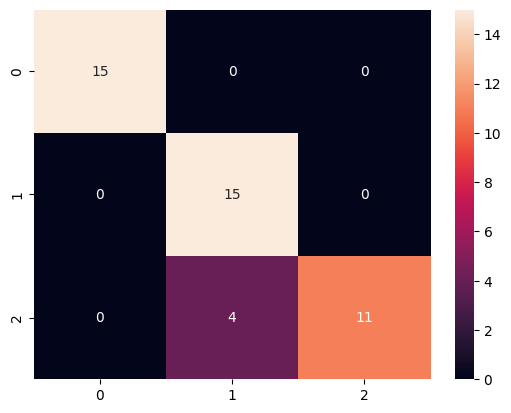

In [34]:
sns.heatmap(data=cmk,annot=True)
plt.show()

In [35]:
pipe=Pipeline(steps=[('scaler',StandardScaler()),('logi',LogisticRegression(random_state=42))])
# logi=LogisticRegression(random_state=42)

In [36]:
pipe.fit(x_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logi', LogisticRegression(random_state=42))])

In [37]:
logipred=pipe.predict(x_test)

In [38]:
pipe.score(x_train,y_train)

0.9809523809523809

In [39]:
cml=confusion_matrix(y_test,logipred)

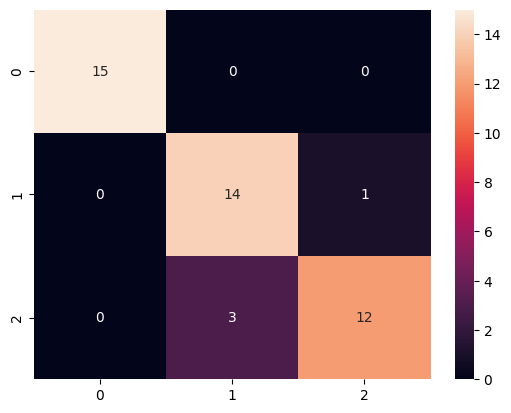

In [40]:
sns.heatmap(data=cml,annot=True)
plt.show()

In [41]:
pipe=Pipeline(steps=[('scaler',StandardScaler()),('SGD',SGDClassifier())])

# sgd=SGDClassifier()

In [42]:
pipe.fit(x_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('SGD', SGDClassifier())])

In [43]:
sgdpt=pipe.predict(x_train)

In [44]:
sgdp=pipe.predict(x_test)

In [45]:
pipe.score(x_train,y_train)

0.9428571428571428

In [46]:
cmt=confusion_matrix(y_train,sgdpt)

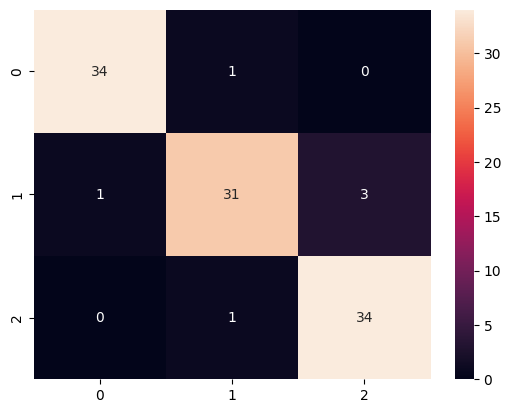

In [47]:
sns.heatmap(data=cmt,annot=True)
plt.show()

In [48]:
cms=confusion_matrix(y_test,sgdp)


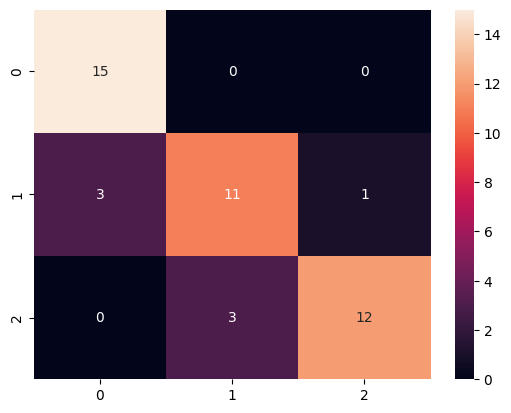

In [49]:
sns.heatmap(data=cms,annot=True)
plt.show()